In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
class DQN(nn.Module):
    """Простая полносвязная сеть для аппроксимации Q-функции."""
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [4]:
# Буфер воспроизведения опыта (Replay Buffer)
class ReplayBuffer:
    """Хранит переходы (s, a, r, s', done) для случайной выборки мини-батчей."""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        # Распаковываем батч в отдельные тензоры
        states, actions, rewards, next_states, dones = zip(*batch)
        return (torch.FloatTensor(states),
                torch.LongTensor(actions).unsqueeze(1),  # для gather
                torch.FloatTensor(rewards).unsqueeze(1),
                torch.FloatTensor(next_states),
                torch.FloatTensor(dones).unsqueeze(1))

    def __len__(self):
        return len(self.buffer)

In [47]:
# Параметры среды и обучения
env = gym.make('LunarLander-v3')
state_dim = env.observation_space.shape[0]  # 8
action_dim = env.action_space.n  # 4

gamma = 0.99

# Гиперпараметры DQN
learning_rate = 1e-3
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
buffer_capacity = 50000
batch_size = 64
target_update_freq = 100  # частота обновления целевой сети (в шагах среды)
episodes = 2000
max_steps = 200

# Инициализация сетей и оптимизатора
policy_net = DQN(state_dim, action_dim)  # Основная сеть, которую мы обучаем
target_net = DQN(state_dim, action_dim)  # Целевая сеть для расчета TD Target
target_net.load_state_dict(policy_net.state_dict())  # копируем веса
target_net.eval()  # целевую сеть не обучаем

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
replay_buffer = ReplayBuffer(buffer_capacity)

# Функция выбора действия (epsilon-greedy с использованием policy_net)
def select_action(state, epsilon):
    if np.random.random() < epsilon:
        return np.random.choice(action_dim)  # Исследование
    else:
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)  # добавляем batch dimension
            q_values = policy_net(state_tensor)
            return q_values.argmax().item()  # Эксплуатация

# Функция для одного шага оптимизации DQN
def optimize_model():
    if len(replay_buffer) < batch_size:
        return  # Недостаточно опыта в буфере

    # Выборка батча из буфера
    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # --- Расчет текущих Q-значений (Q(s, a)) ---
    # gather собирает значения по индексам действий
    current_q_values = policy_net(states).gather(1, actions)

    # --- Расчет целевых Q-значений (TD Target) ---
    with torch.no_grad():
        # Для next_state берем Q-значения из целевой сети и находим max по действиям
        # .max(1, keepdim=True) возвращает (values, indices), нам нужны values
        next_q_values = target_net(next_states).max(1, keepdim=True)[0]
        # TD Target: r + gamma * max(Q_next) * (1 - done)  (если done, то будущая награда = 0)
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    # Функция потерь (MSE между текущими и целевыми Q-значениями)
    loss = nn.MSELoss()(current_q_values, target_q_values)

    # Оптимизация
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Основной цикл обучения DQN
rewards_per_episode_dqn = []
step_counter = 0  # счетчик шагов для обновления целевой сети

for episode in tqdm(range(episodes)):
    state, _ = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        # Выбор действия
        action = select_action(state, epsilon)

        # Выполнение действия
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Сохранение перехода в буфер
        replay_buffer.push(state, action, reward, next_state, done)

        # Переход к следующему состоянию
        state = next_state
        total_reward += reward
        step_counter += 1

        # Шаг оптимизации DQN
        optimize_model()

        # Обновление целевой сети каждые target_update_freq шагов
        if step_counter % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

    # Затухание epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    rewards_per_episode_dqn.append(total_reward)

env.close()

100%|██████████| 2000/2000 [09:38<00:00,  3.46it/s]


In [48]:
def moving_average(data, window=2):
    return np.convolve(data, np.ones(window)/window, mode='valid')

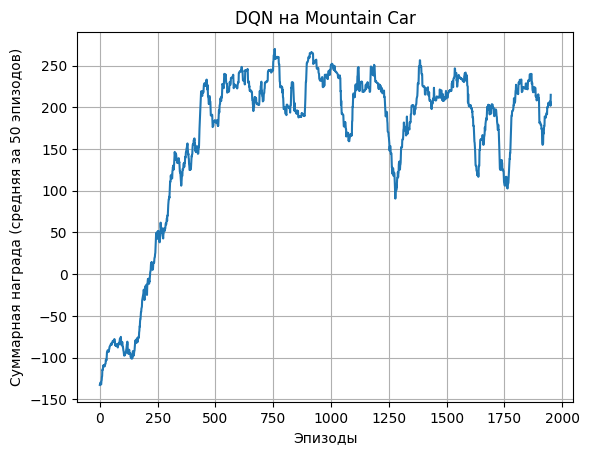

In [49]:
plt.plot(moving_average(rewards_per_episode_dqn, 50))
plt.xlabel('Эпизоды')
plt.ylabel('Суммарная награда (средняя за 50 эпизодов)')
plt.title('DQN на Mountain Car')
plt.grid()
plt.show()

In [50]:
from gymnasium.wrappers import RecordVideo
import time
import os

In [51]:
# Создаем директорию для видео (она появится в папке с ноутбуком/скриптом)
video_dir = "./video_100"
os.makedirs(video_dir, exist_ok=True)

In [55]:
# Функция с решением
def run_episode(env, episode_name):
    observation, info = env.reset()
    total_reward = 0

    print(f"\n--- Запуск {episode_name} ---")

    terminated = False
    truncated = False
    state, _ = env.reset()
    while not terminated and not truncated:
        # Выбор действия
        action = select_action(state, epsilon)
    
        # Выполнение действия
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    
        # Сохранение перехода в буфер
        replay_buffer.push(state, action, reward, next_state, done)
    
        # Переход к следующему состоянию
        state = next_state
        total_reward += reward

    
    


    print(f"Общая награда: {total_reward}")
    return total_reward



In [58]:
# Создаем среду с записью видео
env = gym.make('LunarLander-v3', render_mode='rgb_array')  # rgb_array для записи
env = RecordVideo(
    env,
    video_dir,
    episode_trigger=lambda episode_id: True,  # записывать каждый эпизод
    name_prefix="mountain_car2"
)



# Запускаем эпизод с записью
run_episode(env, "Эпизод 5")

# Закрываем среду
env.close()


--- Запуск Эпизод 5 ---
Общая награда: 273.5821213239046
